# DSN Bootcamp Qualification Hackathon 2026 — ML Track
## Product–Store Total Sales Prediction

### Objective
The objective of this project is to build a regression model that predicts `total_sales` for a product sold at a particular DSN Mart store. The analysis considers both product characteristics and store characteristics, with model performance evaluated primarily using **Root Mean Squared Error (RMSE)**, the official competition metric.

### Workflow
The notebook follows a standard machine-learning workflow:

**Data understanding → Data cleaning → Exploratory data analysis → Feature engineering → Train/validation split → Encoding → Modelling → Evaluation → Competition prediction**


## 1. Import Libraries

The required libraries are imported for data manipulation, visualization, preprocessing, model development and evaluation. A fixed random state is used where applicable to make model results reproducible.

In [155]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

## 2. Load the Dataset

The competition files are read from the supplied ZIP archive. Keeping the training, test and sample-submission files together makes it easier to reproduce the complete modelling and submission workflow.

The training dataset contains the target variable `total_sales`, while the competition test dataset contains only the predictor variables.

## 3. Inspect the Dataset Structure

The dataset structure is examined to understand the number of observations, variable types and overall composition of the data. This step also helps identify categorical and numerical variables that will require different preprocessing strategies.

In [156]:
df = pd.read_csv(r"C:\Users\x\Downloads\dsn-bootcamp-qualification-hackathon-2026-ml-track\train.csv")
df.head(10)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6818 entries, 0 to 6817
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   6818 non-null   object 
 1   product_code         6818 non-null   object 
 2   product_weight_kg    5593 non-null   float64
 3   fat_content          6818 non-null   object 
 4   shelf_visibility     6818 non-null   float64
 5   product_category     6818 non-null   object 
 6   product_price        6818 non-null   float64
 7   store_code           6818 non-null   object 
 8   store_age_years      6818 non-null   int64  
 9   store_size           4899 non-null   object 
 10  store_location_tier  6818 non-null   object 
 11  store_format         6818 non-null   object 
 12  total_sales          6818 non-null   float64
dtypes: float64(4), int64(1), object(8)
memory usage: 692.6+ KB


## 4. Summary Statistics

Descriptive statistics are used to examine the scale, central tendency and spread of the numerical variables. This provides an initial view of variables such as product weight, shelf visibility, product price, store age and total sales.

In [157]:
print(f"Data Shape:{df.shape}")
df.describe()

Data Shape:(6818, 13)


,product_weight_kg,shelf_visibility,product_price,store_age_years,total_sales
count,5593.000000,6818.000000,6818.000000,6818.000000,6818.000000
mean,12.850876,0.065527,140.473623,34.178205,2174.756574
std,4.646542,0.051566,62.413513,8.384574,1697.894956
min,4.482000,0.000000,31.110000,23.000000,32.700000
25%,8.750000,0.026600,93.280000,28.000000,834.792500
50%,12.647000,0.053200,142.065000,33.000000,1790.890000
75%,16.894000,0.093400,185.987500,45.000000,3092.587500
max,21.883000,0.320100,273.040000,47.000000,12996.820000


## 5. Check for Duplicate Records

Duplicate observations can unnecessarily increase the influence of repeated records during model training. The dataset is therefore checked for exact duplicate rows before further analysis.

In [158]:
df.duplicated().sum()

np.int64(0)

## 6. Assess Missing Values

Missing-value counts are examined for every variable. This identifies the columns that require imputation before exploratory analysis and modelling.

In [159]:
df.isnull().sum()

id                        0
product_code              0
product_weight_kg      1225
fat_content               0
shelf_visibility          0
product_category          0
product_price             0
store_code                0
store_age_years           0
store_size             1919
store_location_tier       0
store_format              0
total_sales               0
dtype: int64

## 7. Examine Product Weight Before Imputation

`product_weight_kg` contains missing observations. Before selecting an imputation method, its distribution and skewness are examined. The mean is used when the distribution does not show severe distortion and provides a simple central estimate while retaining all observations.

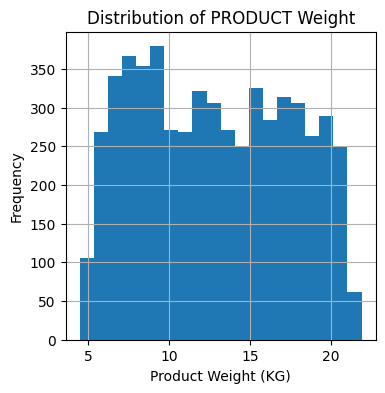

In [160]:
df['product_weight_kg'].skew()

plt.figure(figsize=(4,4))
df['product_weight_kg'].hist(bins=20)
plt.xlabel('Product Weight (KG)')
plt.ylabel('Frequency')
plt.title('Distribution of PRODUCT Weight')
plt.show()

## 8. Impute Missing Product Weights

Missing product weights are replaced with the mean product weight calculated from the training data. The value is stored separately so that the same training-derived imputation rule can later be applied to the competition test data.


In [161]:
df['product_weight_kg'] = df['product_weight_kg'].fillna(df['product_weight_kg'].mean())

In [162]:
pd.crosstab(
    [df['store_format'], df['store_location_tier']],
    df['store_size']
)

store_size                                Large  Medium  Small
store_format         store_location_tier                      
Corner Shop          Tier_1                   0       0    427
Flagship Hypermarket Tier_3                   0     748      0
Standard Supermarket Tier_1                   0     728    754
                     Tier_2                   0       0    752
                     Tier_3                 748       0      0
Superstore           Tier_3                   0     742      0

## 9. Investigate Missing Store Size

`store_size` is categorical, so simply replacing all missing values with the overall mode may ignore useful store information. The distribution is first inspected to understand the observed categories and the extent of missingness.

In [163]:
df['store_size'].value_counts(dropna=False)

store_size
Medium    2218
Small     1933
NaN       1919
Large      748
Name: count, dtype: int64

## 10. Examine Store Size by Store Characteristics

A cross-tabulation of `store_format`, `store_location_tier` and `store_size` is used to determine whether store size follows consistent patterns within similar store groups. This supports a more context-aware imputation strategy than using one global value.

In [164]:
pd.crosstab([df['store_format'], df['store_location_tier']], df['store_size'])

store_size                                Large  Medium  Small
store_format         store_location_tier                      
Corner Shop          Tier_1                   0       0    427
Flagship Hypermarket Tier_3                   0     748      0
Standard Supermarket Tier_1                   0     728    754
                     Tier_2                   0       0    752
                     Tier_3                 748       0      0
Superstore           Tier_3                   0     742      0

## 11. Group-Based Store Size Imputation

For each combination of store format and location tier, the most frequent observed store size is calculated. Missing `store_size` values are then filled with the mode of their corresponding group. This preserves relationships already present in the training data.

In [165]:
group_mode = df.groupby(
    ['store_format', 'store_location_tier'])['store_size'].transform(
    lambda x: x.mode().iloc[0] if not x.mode().empty else None)

df['store_size'] = df['store_size'].fillna(group_mode)

## 12. Investigate Store Sizes Still Missing

Some groups may have no observed store-size value from which a mode can be calculated. The remaining missing observations are inspected using store format and location tier to identify the unresolved pattern.

In [166]:
df['store_size'].value_counts(dropna=False)

store_size
Small     3413
Medium    2218
Large      748
NaN        439
Name: count, dtype: int64

## 13. Identify the Store Behind the Remaining Missing Values

The unresolved observations are examined by `store_code`. This determines whether they belong to a particular store and allows the imputation decision to be based on the store's known characteristics rather than an arbitrary overall replacement.

In [167]:
df[df['store_size'].isna()][
    ['store_format', 'store_location_tier']
].value_counts()

store_format  store_location_tier
Corner Shop   Tier_3                 439
Name: count, dtype: int64

In [168]:
df[df['store_size'].isna()][
    ['store_code', 'store_format', 'store_location_tier']
].value_counts()

store_code  store_format  store_location_tier
STORE-JOR   Corner Shop   Tier_3                 439
Name: count, dtype: int64

## 14. Inspect STORE-JOR

The remaining missing values belong to `STORE-JOR`. Its store characteristics are inspected to confirm whether the store has any observed size elsewhere in the training data and to understand the information available for a final imputation decision.

In [169]:
df[df['store_code'] == 'STORE-JOR'][
    ['store_code', 'store_age_years', 'store_size',
     'store_location_tier', 'store_format']
].drop_duplicates()

,store_code,store_age_years,store_size,store_location_tier,store_format
9,STORE-JOR,34,NaN,Tier_3,Corner Shop


## 15. Complete Store Size Imputation

`STORE-JOR` is a Corner Shop, and the observed Corner Shop records in the training data are associated with the Small store-size category. The remaining missing `store_size` values for this store are therefore assigned `Small`.

In [170]:
df.loc[
    (df['store_code'] == 'STORE-JOR') &
    (df['store_size'].isna()),
    'store_size'
] = 'Small'

## 16. Confirm Data Completeness

After imputation, the training dataset is checked again to verify that no missing values remain before exploratory analysis and feature engineering.


In [171]:
df.isnull().sum()

id                     0
product_code           0
product_weight_kg      0
fat_content            0
shelf_visibility       0
product_category       0
product_price          0
store_code             0
store_age_years        0
store_size             0
store_location_tier    0
store_format           0
total_sales            0
dtype: int64

## 17. Preserve the Identifier and Prepare the Analysis Dataset

The `id` column uniquely identifies rows but does not describe the product or store itself. It is retained separately for reference and excluded from model features to reduce the risk of the model learning arbitrary row identifiers.

In [172]:
train_ids = df['id'].copy()
df = df.drop(columns='id')

print("Analysis data shape:", df.shape)


Analysis data shape: (6818, 12)


# Exploratory Data Analysis

The exploratory analysis examines the distribution of store characteristics and their relationships with `total_sales`. The purpose is to identify patterns that may be useful for feature engineering and model development.

## 18. Distribution of Store Formats

The number of observations belonging to each store format is visualized to understand how the training data are distributed across outlet types.

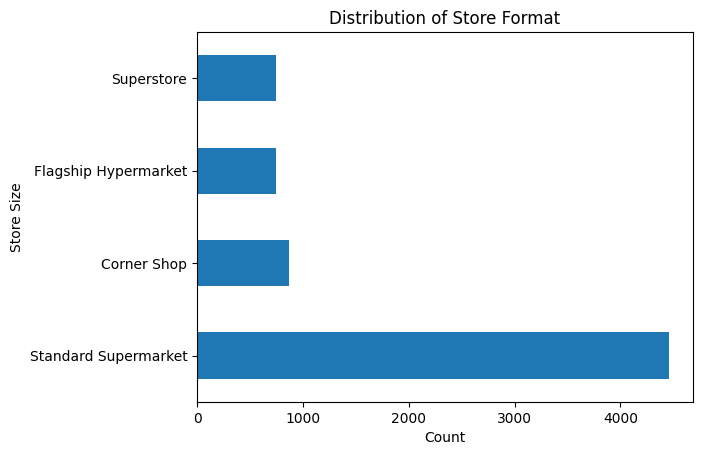

In [173]:
df['store_format'].value_counts().plot(kind='barh')
plt.ylabel('Store Size')
plt.xlabel('Count')
plt.title('Distribution of Store Format')
plt.show()

## 19. Average Sales by Store Format

Average `total_sales` is compared across store formats. This helps assess whether outlet type is associated with meaningful differences in product-level sales.

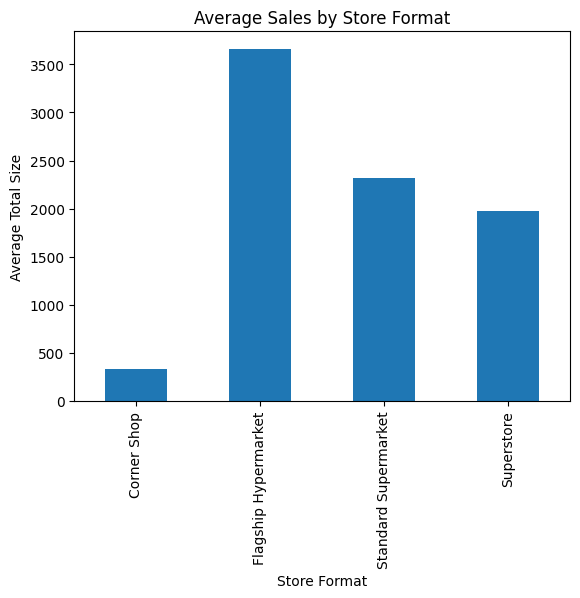

In [174]:
df.groupby('store_format')['total_sales'].mean().plot(kind='bar')
plt.xlabel('Store Format')
plt.ylabel('Average Total Size')
plt.title('Average Sales by Store Format')
plt.show()

## 20. Product Price and Total Sales

A scatter plot is used to examine the relationship between product price and total sales. This is useful for identifying whether higher-priced products tend to be associated with higher sales values and whether the relationship appears linear or nonlinear.

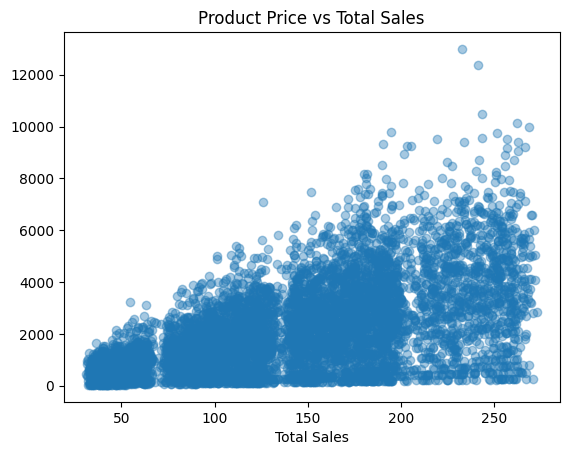

In [175]:
plt.scatter(df['product_price'], df['total_sales'], alpha=0.4)
plt.xlabel('Product Prize')
plt.xlabel('Total Sales')
plt.title('Product Price vs Total Sales')
plt.show()

## 21. Product Weight and Total Sales

The relationship between product weight and total sales is examined to determine whether product weight appears to contribute directly to sales variation.

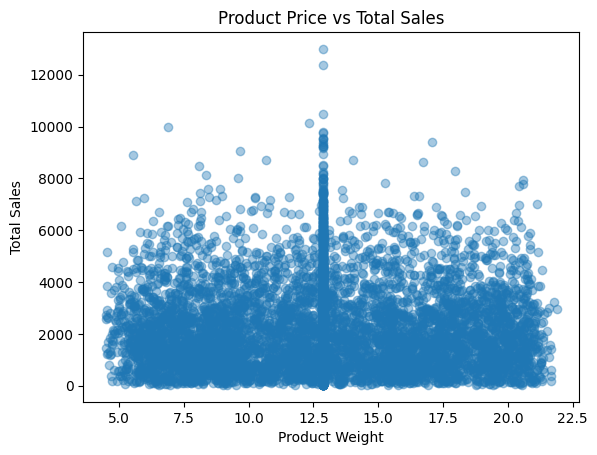

In [176]:
plt.scatter(df['product_weight_kg'], df['total_sales'], alpha=0.4)
plt.xlabel('Product Weight')
plt.ylabel('Total Sales')
plt.title('Product Price vs Total Sales')
plt.show()

## 22. Average Sales by Store Size

Average sales are compared across Small, Medium and Large stores. This provides an initial view of whether store scale is associated with product-level sales performance.


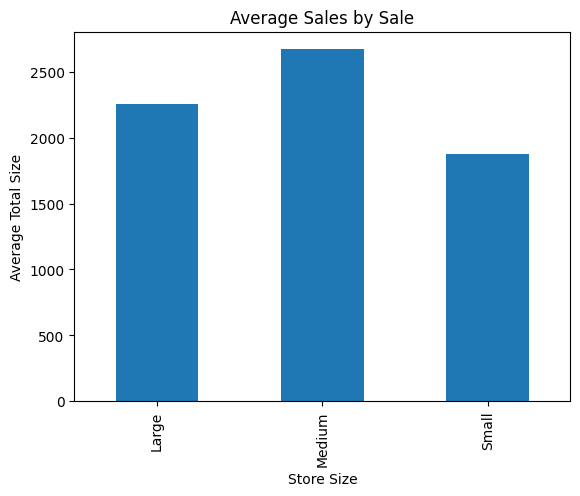

In [177]:
df.groupby('store_size')['total_sales'].mean().plot(kind='bar')
plt.xlabel('Store Size')
plt.ylabel('Average Total Size')
plt.title('Average Sales by Sale')
plt.show()

## 23. Correlation Among Numerical Variables

A correlation heatmap summarizes linear relationships among the main numerical predictors and the target. Correlation does not establish causation, but it helps identify variables that may have stronger linear associations with `total_sales` and highlights possible relationships among predictors.

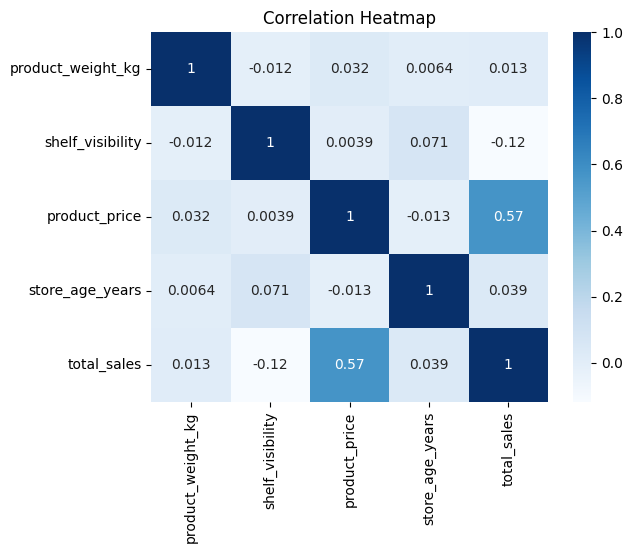

In [178]:
data = ['product_weight_kg','shelf_visibility', 'product_price', 'store_age_years','total_sales']
corr = df[data].corr()
sns.heatmap(corr, cmap='Blues', annot=True, cbar=True, linewidths=0, linecolor='white')
plt.title('Correlation Heatmap')
plt.show()

# Feature Engineering

Feature engineering creates additional variables from the available product and store information. The aim is to expose potentially useful relationships to the models without using information from the target variable.

## 24. Price per Unit Weight

`price_per_weight` combines product price and product weight. It represents the product's price relative to its weight and may capture differences that are not represented by price or weight alone.

In [179]:
df['price_per_weight'] = df['product_price'] / df['product_weight_kg']

## 25. Price per Weight and Total Sales

The engineered `price_per_weight` feature is visualized against total sales to assess whether it reveals a useful relationship with the target.

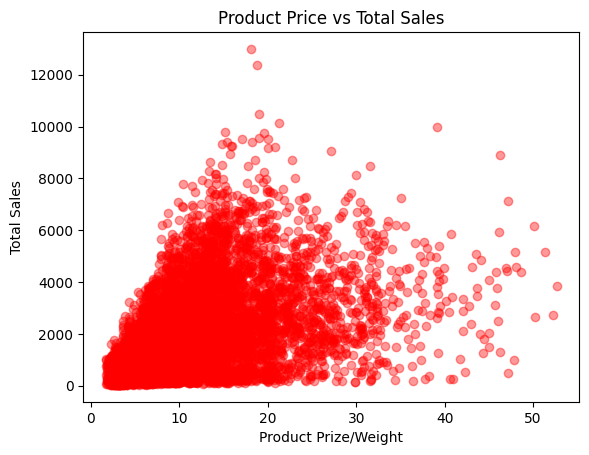

In [180]:
plt.scatter(df['price_per_weight'], df['total_sales'], alpha=0.4, color='r')
plt.xlabel('Product Prize/Weight')
plt.ylabel('Total Sales')
plt.title('Product Price vs Total Sales')
plt.show()

## 26. Store Age Groups

Although `store_age_years` is retained as a numerical variable, an additional grouped version is created to capture possible nonlinear differences between relatively younger and more established stores. The original numerical age remains available to the model.

In [181]:
df['store_age_group'] = pd.cut(df['store_age_years'], bins=[0,30,40,float('inf')], labels=['Youth', 'Young-Adults', 'Adults'])

## 27. Distribution of Store Age Groups

The engineered age groups are examined to ensure that the categories contain observations and to understand their representation in the training data.

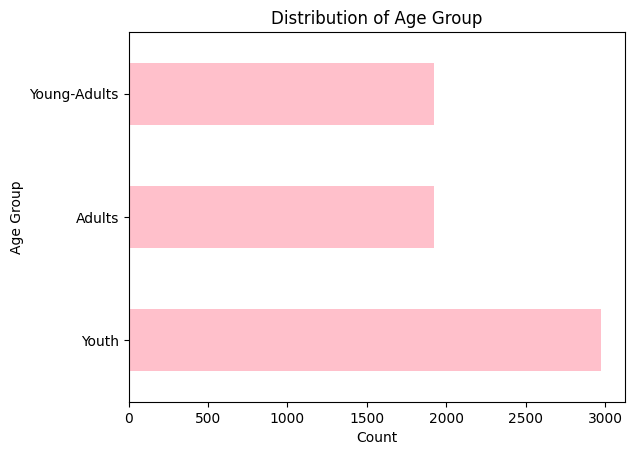

In [183]:
df['store_age_group'].value_counts().plot(kind='barh', color='pink')
plt.ylabel('Age Group')
plt.xlabel('Count')
plt.title('Distribution of Age Group')
plt.show()

## 28. Average Sales by Store Age Group

Average total sales are compared across the engineered store-age groups to determine whether store maturity may capture differences in sales performance.

C:\Users\x\AppData\Local\Temp\ipykernel_18600\1946364066.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('store_age_group')['total_sales'].mean().plot(kind='bar', color='purple')


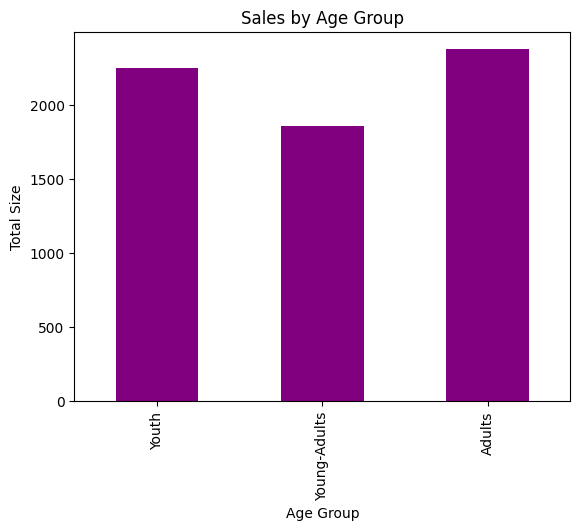

In [184]:
df.groupby('store_age_group')['total_sales'].mean().plot(kind='bar', color='purple')
plt.xlabel('Age Group')
plt.ylabel('Total Size')
plt.title('Sales by Age Group')
plt.show()

## 29. Store Profile Interaction Feature

`store_profile` combines `store_format` and `store_location_tier`. This interaction feature allows the model to distinguish, for example, the same store format operating in different location tiers rather than treating the two variables only as independent effects.

In [185]:
df['store_profile'] = (df['store_format'].astype(str) + '_' + df['store_location_tier'].astype(str))

## 30. Review the Engineered Dataset

The first rows are inspected after feature engineering to confirm that the new variables have been created as intended.

In [186]:
df.head()

,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales,price_per_weight,store_age_group,store_profile
0,PRD-PRFP9S,14.252000,Low Fat,0.0271,Frozen Foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98,5.709374,Adults,Standard Supermarket_Tier_3
1,PRD-PXXK71,7.698000,Low Fat,0.0720,HEALTH AND HYGIENE,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13,5.462458,Young-Adults,Standard Supermarket_Tier_1
2,PRD-V5MOIJ,14.264000,Regular,0.0421,Canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85,2.898906,Young-Adults,Standard Supermarket_Tier_1
3,PRD-UN5Z3J,12.850876,Regular,0.0449,soft drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72,13.567169,Adults,Flagship Hypermarket_Tier_3
4,PRD-6RDQYB,10.338000,Regular,0.0120,meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36,19.642097,Youth,Standard Supermarket_Tier_2


# Model Preparation and Encoding

The target is separated from the predictors before data-dependent encoding. The training data are then divided into training and validation subsets. This order is important because frequency encoding learns category frequencies from data; learning those frequencies from the complete dataset would allow information from the validation set to influence model preparation.

## 31. Separate Predictors and Target and Create a Validation Set

An 80:20 split is used. The validation set provides an unseen portion of the training data for estimating model performance before generating predictions for the official competition test set.

In [187]:
X = df.drop(columns='total_sales')
y = df['total_sales']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    random_state=42,
    test_size=0.2
)

X_train = X_train.copy()
X_test = X_test.copy()

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5454, 14)
X_test: (1364, 14)
y_train: (5454,)
y_test: (1364,)


## 32. Apply Fixed Category Mappings

`store_size` and `store_location_tier` have ordered category labels, while `fat_content` is binary. Predefined mappings convert these values to numbers without learning anything from the validation set. The engineered store-age groups are also represented numerically while the original `store_age_years` variable is retained.


In [188]:
size_mapping = {
    'Small': 0,
    'Medium': 1,
    'Large': 2
}

tier_mapping = {
    'Tier_3': 0,
    'Tier_2': 1,
    'Tier_1': 2
}

age_mapping = {
    'Youth': 0,
    'Young-Adults': 1,
    'Adults': 2
}

fat_mapping = {
    'Low Fat': 0,
    'Regular': 1
}

for data in [X_train, X_test]:
    data['store_size'] = data['store_size'].map(size_mapping)
    data['store_location_tier'] = data['store_location_tier'].map(tier_mapping)
    data['store_age_group'] = data['store_age_group'].map(age_mapping)
    data['fat_content'] = data['fat_content'].map(fat_mapping)


## 33. Frequency Encode Nominal Variables

Nominal variables do not have a natural numerical order. Frequency encoding replaces each category with its relative frequency in the training subset. This avoids imposing an artificial ranking and keeps the feature space compact, which is useful for variables such as product and store codes.

The frequency mappings are learned **only from `X_train`** and then applied unchanged to `X_val`. Categories not seen during training are assigned a frequency of zero.

In [189]:
frequency_cols = [
    'product_code',
    'product_category',
    'store_code',
    'store_format',
    'store_profile'
]

frequency_mappings = {}

for col in frequency_cols:
    freq = X_train[col].value_counts(normalize=True)
    frequency_mappings[col] = freq

    X_train[col] = X_train[col].map(freq)
    X_test[col] = X_test[col].map(freq).fillna(0)


In [190]:
df.head()

,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales,price_per_weight,store_age_group,store_profile
0,PRD-PRFP9S,14.252000,Low Fat,0.0271,Frozen Foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98,5.709374,Adults,Standard Supermarket_Tier_3
1,PRD-PXXK71,7.698000,Low Fat,0.0720,HEALTH AND HYGIENE,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13,5.462458,Young-Adults,Standard Supermarket_Tier_1
2,PRD-V5MOIJ,14.264000,Regular,0.0421,Canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85,2.898906,Young-Adults,Standard Supermarket_Tier_1
3,PRD-UN5Z3J,12.850876,Regular,0.0449,soft drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72,13.567169,Adults,Flagship Hypermarket_Tier_3
4,PRD-6RDQYB,10.338000,Regular,0.0120,meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36,19.642097,Youth,Standard Supermarket_Tier_2


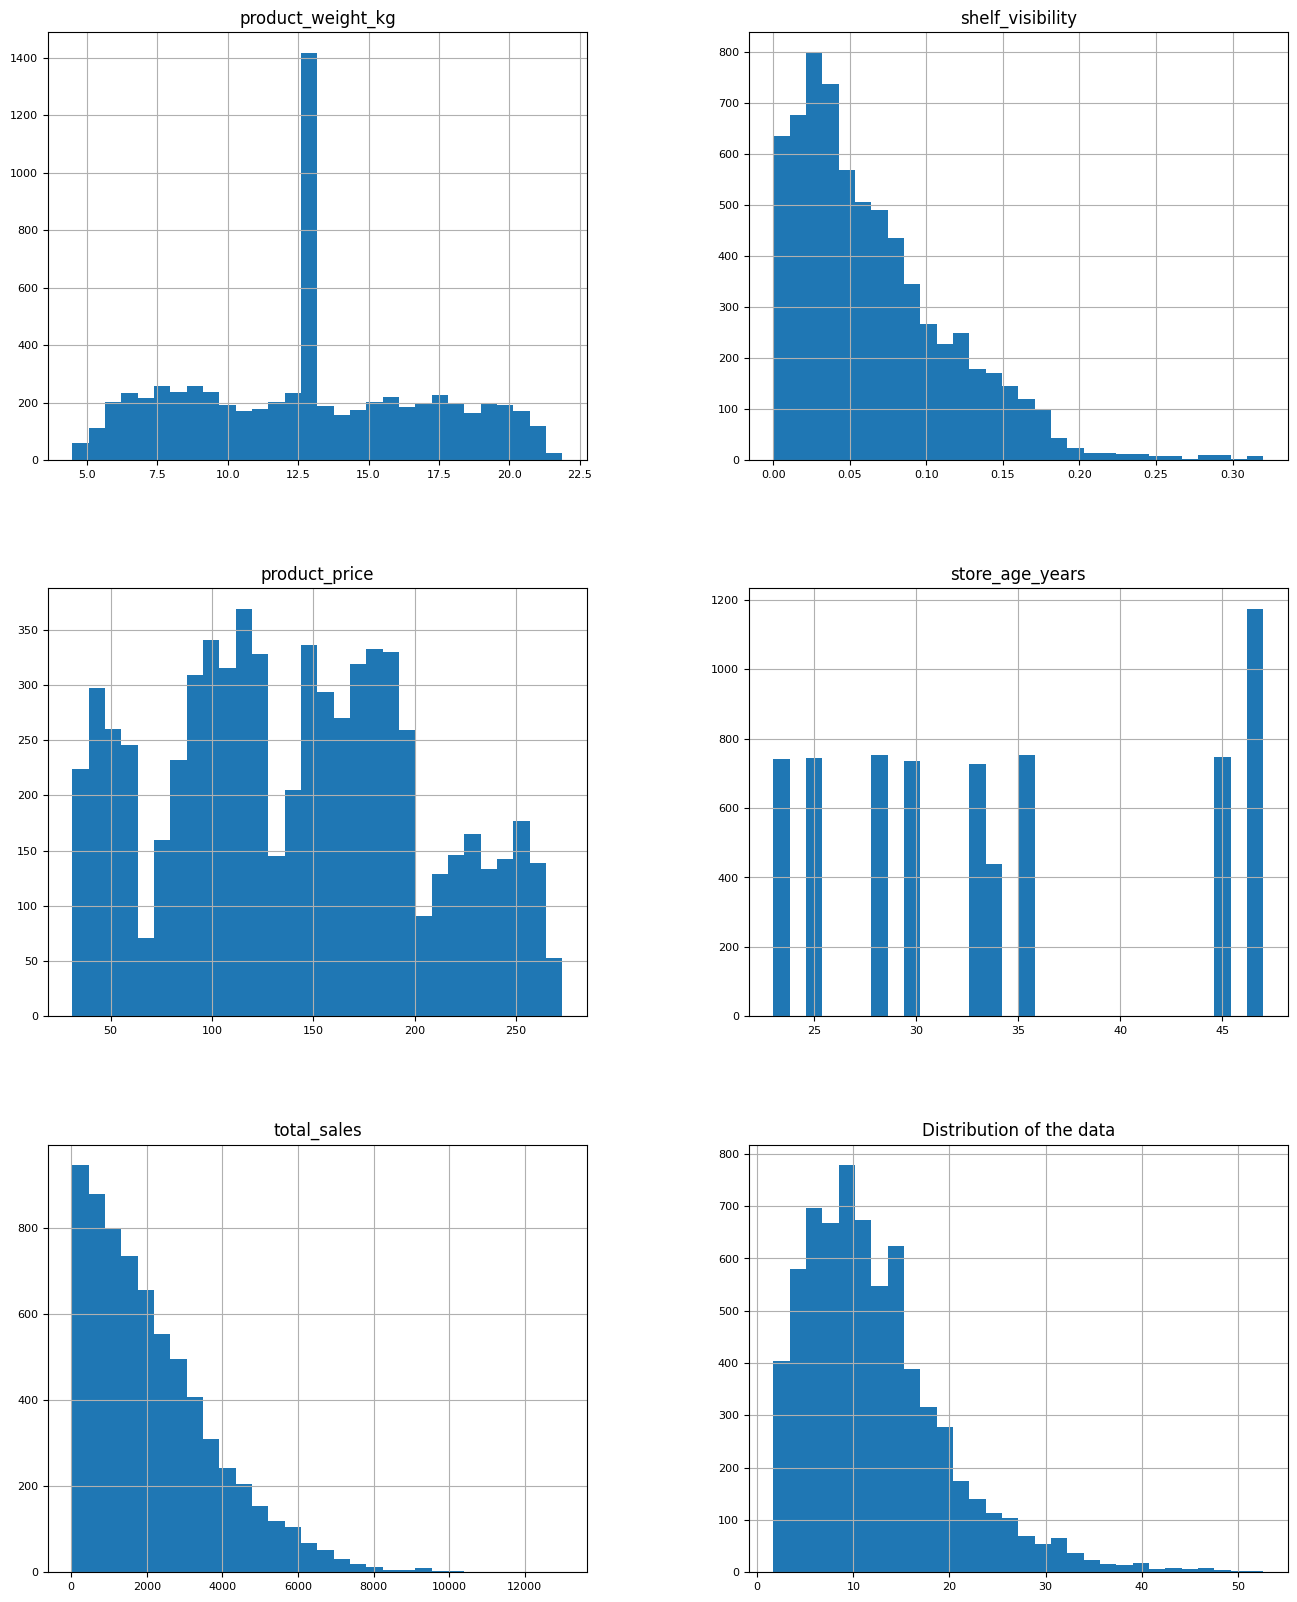

In [191]:
df.hist(figsize=(16,20), bins=30, xlabelsize=8, ylabelsize=8)
plt.title('Distribution of the data')
plt.show()

## 34. Validate the Model Inputs

Before fitting the models, the processed predictors are checked for remaining text/category variables and missing values. The models used below require numerical, non-missing inputs.

In [192]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5454, 14)
X_test: (1364, 14)
y_train: (5454,)
y_test: (1364,)


In [193]:
X_train.select_dtypes(include=['object', 'category']).columns

Index(['store_age_group'], dtype='object')

# Model Development

Three regression algorithms are evaluated. Linear Regression provides a simple baseline, while Random Forest and Gradient Boosting can capture nonlinear relationships and interactions among product and store characteristics.

In [ ]:
## 35. Linear Regression Baseline

Linear Regression establishes a baseline for the prediction task. Comparing more flexible models against this baseline helps determine whether nonlinear relationships provide meaningful improvements.

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression")
print("MAE:", lr_mae)
print("RMSE:", lr_rmse)
print("R²:", lr_r2)


## 36. Random Forest Regressor

Random Forest combines many decision trees and can model nonlinear relationships without requiring the predictors to follow a linear pattern. It is included to test whether interactions among product and store characteristics improve sales prediction.

In [ ]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R²:", rf_r2)

## 37. Gradient Boosting Regressor

Gradient Boosting builds trees sequentially, with each stage attempting to reduce errors made by the previous stages. It is evaluated because boosting methods often perform well on structured tabular regression problems.

In [ ]:
gbr = GradientBoostingRegressor(
    random_state=42
)

gbr.fit(X_train, y_train)
y_pred_gbr = gbr.predict(X_test)

gbr_mae = mean_absolute_error(y_test, y_pred_gbr)
gbr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
gbr_r2 = r2_score(y_test, y_pred_gbr)

print("Gradient Boosting")
print("MAE:", gbr_mae)
print("RMSE:", gbr_rmse)
print("R²:", gbr_r2)


## 38. Compare Validation Performance

The models are placed in a single comparison table and sorted by RMSE. The model with the lowest validation RMSE provides the strongest performance on this validation split.

In [ ]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'Gradient Boosting'
    ],
    'MAE': [
        lr_mae,
        rf_mae,
        gbr_mae
    ],
    'RMSE': [
        lr_rmse,
        rf_rmse,
        gbr_rmse
    ],
    'R2': [
        lr_r2,
        rf_r2,
        gbr_r2
    ]
})

results = results.sort_values('RMSE').reset_index(drop=True)
results


## 39. Visualize RMSE Across Models

A bar chart makes the differences in validation RMSE easier to compare. Because lower RMSE is better, shorter bars represent stronger validation performance.

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(results['Model'], results['RMSE'])
plt.xlabel('Model')
plt.ylabel('Validation RMSE')
plt.title('Model Comparison Based on Validation RMSE')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


# Competition Test Prediction

After validation, the same preprocessing logic must be applied to the official `test.csv`. Importantly, transformations used for the competition test data are learned from the training data rather than from the test data.

The final section rebuilds the preprocessing rules using all available training observations, fits the selected model on the full training dataset, and generates predictions in the format required by `sample_submission.csv`.

## 40. Prepare Full Training and Competition Test Data

Fresh copies of the original competition files are loaded so that the final model can be trained on all available training observations. The test IDs are preserved for the submission file.

In [ ]:
full_train = pd.read_csv(r'Downloads/dsn-bootcamp-qualification-hackathon-2026-ml-track/train.csv')
final_test = pd.read_csv(r'Downloads/dsn-bootcamp-qualification-hackathon-2026-ml-track/test.csv')
submission = pd.read_csv(r'Downloads/dsn-bootcamp-qualification-hackathon-2026-ml-track/sample_submission.csv')

test_ids = final_test['id'].copy()

print("Training data:", full_train.shape)
print("Test data:", final_test.shape)
print("Submission template:", submission.shape)

## 41. Apply Training-Derived Missing-Value Rules

The mean product weight is calculated from the full training data and applied to both datasets. For `store_size`, a mapping based on store format and location tier is learned from observed training records and used for both training and test observations. Any unresolved Corner Shop case is assigned `Small`, consistent with the pattern identified during exploratory cleaning.

In [ ]:
final_weight_mean = full_train['product_weight_kg'].mean()

full_train['product_weight_kg'] = (
    full_train['product_weight_kg'].fillna(final_weight_mean)
)
final_test['product_weight_kg'] = (
    final_test['product_weight_kg'].fillna(final_weight_mean)
)

store_size_lookup = (
    full_train.dropna(subset=['store_size'])
    .groupby(['store_format', 'store_location_tier'])['store_size']
    .agg(lambda x: x.mode().iloc[0])
)

def fill_store_size(data, lookup):
    data = data.copy()

    missing_mask = data['store_size'].isna()

    for idx in data.index[missing_mask]:
        key = (
            data.at[idx, 'store_format'],
            data.at[idx, 'store_location_tier']
        )

        if key in lookup.index:
            data.at[idx, 'store_size'] = lookup.loc[key]

    corner_mask = (
        data['store_size'].isna()
        & data['store_format'].eq('Corner Shop')
    )
    data.loc[corner_mask, 'store_size'] = 'Small'

    return data

full_train = fill_store_size(full_train, store_size_lookup)
final_test = fill_store_size(final_test, store_size_lookup)

print("Training missing store size:", full_train['store_size'].isna().sum())
print("Test missing store size:", final_test['store_size'].isna().sum())


## 42. Recreate Engineered Features

The same feature definitions used during model development are recreated for the full training and competition test datasets. Using identical feature definitions ensures that the model receives the same input structure during training and prediction.

In [ ]:
def add_features(data):
    data = data.copy()

    data['price_per_weight'] = (
        data['product_price'] / data['product_weight_kg']
    )

    data['store_age_group'] = pd.cut(
        data['store_age_years'],
        bins=[0, 30, 40, float('inf')],
        labels=['Youth', 'Young-Adults', 'Adults'],
        include_lowest=True
    )

    data['store_profile'] = (
        data['store_format'].astype(str)
        + '_'
        + data['store_location_tier'].astype(str)
    )

    return data

full_train = add_features(full_train)
final_test = add_features(final_test)


## 43. Separate the Final Target and Remove Row Identifiers

The target is separated from the full training data, while `id` is removed from both model-input datasets. The test IDs remain stored separately for the final submission.

In [ ]:
X_full = full_train.drop(columns=['id', 'total_sales']).copy()
y_full = full_train['total_sales'].copy()

X_comp = final_test.drop(columns='id').copy()


## 44. Apply Fixed Mappings to the Full Datasets

The same predefined category mappings used during validation are applied to the complete training data and the official competition test data.

In [ ]:
for data in [X_full, X_comp]:
    data['store_size'] = data['store_size'].map(size_mapping)
    data['store_location_tier'] = data['store_location_tier'].map(tier_mapping)
    data['store_age_group'] = data['store_age_group'].map(age_mapping)
    data['fat_content'] = data['fat_content'].map(fat_mapping)


In [ ]:
## 45. Learn Final Frequency Encodings from the Full Training Data

For the final competition model, category frequencies are recalculated using all available training observations. The resulting mappings are then applied to the competition test data. Unseen test categories are assigned zero.

In [ ]:
final_frequency_mappings = {}

for col in frequency_cols:
    freq = X_full[col].value_counts(normalize=True)
    final_frequency_mappings[col] = freq

    X_full[col] = X_full[col].map(freq)
    X_comp[col] = X_comp[col].map(freq).fillna(0)


In [ ]:
print("Same feature columns:", list(X_full.columns) == list(X_comp.columns))
print("Non-numeric training columns:",
      list(X_full.select_dtypes(include=['object', 'category']).columns))
print("Non-numeric test columns:",
      list(X_comp.select_dtypes(include=['object', 'category']).columns))
print("Training missing values:", X_full.isnull().sum().sum())
print("Test missing values:", X_comp.isnull().sum().sum())


## 47. Select and Fit the Final Model

The model with the lowest validation RMSE is selected automatically from the three models evaluated above. A fresh instance of that model is then fitted using the complete training dataset so that no available labelled observation is discarded before competition prediction.

In [ ]:
best_model_name = results.loc[0, 'Model']

if best_model_name == 'Linear Regression':
    final_model = LinearRegression()
elif best_model_name == 'Random Forest':
    final_model = RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
else:
    final_model = GradientBoostingRegressor(
        random_state=42
    )

print("Selected model:", best_model_name)

final_model.fit(X_full, y_full)


## 48. Generate Competition Predictions

The fitted final model is used to predict `total_sales` for every row in the official competition test set.

In [ ]:
competition_predictions = final_model.predict(X_comp)

print("Number of predictions:", len(competition_predictions))
print("First five predictions:", competition_predictions[:5])

In [ ]:
## 49. Create the Submission File

The predictions are inserted into the provided sample-submission structure. Using the supplied template preserves the exact column names and row order expected by the competition.

In [ ]:
submission['id'] = test_ids.values
submission['total_sales'] = competition_predictions

submission.head()

## 50. Save the Kaggle Submission

The completed submission is saved as `submission.csv` without an additional index column. This file is ready to upload to the competition platform.

In [ ]:
submission.to_csv('submission.csv', index=False)

print("submission.csv created successfully.")
print("Submission shape:", submission.shape)

# Conclusion

This notebook developed an end-to-end regression workflow for predicting product-level sales across DSN Mart stores. Missing values were handled using both statistical and group-based imputation, exploratory analysis was used to investigate product and store relationships, and additional product/store features were engineered without using the target variable.

To reduce validation leakage, data-dependent frequency encoding was learned from the training subset and applied to the validation subset. Linear Regression, Random Forest and Gradient Boosting models were evaluated using RMSE as the primary metric because it is the official competition scoring measure.

For the final competition prediction, preprocessing rules were learned from the full training data and applied consistently to `test.csv`. The model with the lowest validation RMSE was then fitted on all labelled observations and used to generate the final submission.
